In [1]:
import os
import string
import time
from collections import Counter
from datetime import datetime, timedelta

import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Font
from matplotlib import font_manager
from tqdm import tqdm

font_path = "/workspace/fonts/"
font_list = os.listdir(font_path)
for font_file in font_list:
    try:
        font_manager.fontManager.addfont(font_path + font_file)
    except:
        raise Exception(f"Cannot Load {font_path+font_file}")


"""
N_ROW = 1
N_COL = 2
X_SIZE = 6
Y_SIZE = 4
DPI = 300
# plt.rcParams['font.family'] = ['NanumSquare', 'Helvetica']
plt.rcParams['font.family'] = ['Helvetica', 'NanumSquare']

fig=plt.figure(figsize = (X_SIZE*N_COL,Y_SIZE*N_ROW), dpi=DPI)
spec = gridspec.GridSpec(ncols=N_COL, nrows=N_ROW, figure=fig)#, width_ratios=[1,1,.1], wspace=.3)
axes = []

axi=0
ax = fig.add_subplot(spec[axi//N_COL,axi%N_COL]) # row, col
ax.text(-.05, 1.02, '%s'%(string.ascii_uppercase[axi]), transform=ax.transAxes, size=12, weight='bold')

x.plot('value', cmap='Blues', ax=ax, legend=True)
plt.title('Total Amount of Fundings [KRW]')
plt.text(133.3, 38.7, 'log10', fontsize=8)
plt.ylabel('lat')
plt.xlabel('lon')

axi=1
ax = fig.add_subplot(spec[axi//N_COL,axi%N_COL]) # row, col
ax.text(-.05, 1.02, '%s'%(string.ascii_uppercase[axi]), transform=ax.transAxes, size=12, weight='bold')
plt.plot(10**x.sort_values('value')['value'].values[::-1], 'o-')
plt.ylabel('Total Amount of Fundings [KRW]')
plt.xlabel('Rank of Area')
plt.yscale('log')
"""

"\nN_ROW = 1\nN_COL = 2\nX_SIZE = 6\nY_SIZE = 4\nDPI = 300\n# plt.rcParams['font.family'] = ['NanumSquare', 'Helvetica']\nplt.rcParams['font.family'] = ['Helvetica', 'NanumSquare']\n\nfig=plt.figure(figsize = (X_SIZE*N_COL,Y_SIZE*N_ROW), dpi=DPI)\nspec = gridspec.GridSpec(ncols=N_COL, nrows=N_ROW, figure=fig)#, width_ratios=[1,1,.1], wspace=.3)\naxes = []\n\naxi=0\nax = fig.add_subplot(spec[axi//N_COL,axi%N_COL]) # row, col\nax.text(-.05, 1.02, '%s'%(string.ascii_uppercase[axi]), transform=ax.transAxes, size=12, weight='bold')\n\nx.plot('value', cmap='Blues', ax=ax, legend=True)\nplt.title('Total Amount of Fundings [KRW]')\nplt.text(133.3, 38.7, 'log10', fontsize=8)\nplt.ylabel('lat')\nplt.xlabel('lon')\n\naxi=1\nax = fig.add_subplot(spec[axi//N_COL,axi%N_COL]) # row, col\nax.text(-.05, 1.02, '%s'%(string.ascii_uppercase[axi]), transform=ax.transAxes, size=12, weight='bold')\nplt.plot(10**x.sort_values('value')['value'].values[::-1], 'o-')\nplt.ylabel('Total Amount of Fundings [KRW]')\

In [2]:
import zipfile

import orjson

path = "/Data/Data/RoR/"
zf = "v1.51-2024-08-21-ror-data.zip"

with zipfile.ZipFile(path + zf, "r") as zipObj:
    listOfFileNames = zipObj.namelist()
    # print(listOfFileNames)
    fileName = "v1.51-2024-08-21-ror-data_schema_v2.json"
    # zipRead = zipObj.read(fileName)
    with zipObj.open(fileName) as json_file:
        extracted_dict = orjson.loads(json_file.read())

In [3]:
len(extracted_dict)

110484

In [32]:
import sys

import pymysql

sys.path.append("/workspace/1.1.KISTI_DB_Manager/")

import importlib as imp

from KISTI_DB_Manager import manage, plot, preview, processing

imp.reload(manage), imp.reload(preview), imp.reload(processing), imp.reload(plot)

(<module 'KISTI_DB_Manager.manage' from '/workspace/1.1.KISTI_DB_Manager/KISTI_DB_Manager/manage.py'>,
 <module 'KISTI_DB_Manager.preview' from '/workspace/1.1.KISTI_DB_Manager/KISTI_DB_Manager/preview.py'>,
 <module 'KISTI_DB_Manager.processing' from '/workspace/1.1.KISTI_DB_Manager/KISTI_DB_Manager/processing.py'>,
 <module 'KISTI_DB_Manager.plot' from '/workspace/1.1.KISTI_DB_Manager/KISTI_DB_Manager/plot.py'>)

# Raw

In [7]:
json_data = extracted_dict[:]

origin = ""
sep = "__"
forced = {}
index_key = "id"
except_keys = []

df, df_subs, excepted, sample = processing.json_parsing(
    json_data,
    origin=origin,
    sep=sep,
    forced=forced,
    index_key=index_key,
    except_keys=except_keys,
)

STEP 1. Analyze JSON Structure:
STEP 2. Regularize JSON:


	: 100%|█████████████████████████████| 110484/110484 [00:09<00:00, 11666.28it/s]


STEP 3. Extract Data from Regularized JSON:


	: 100%|███████████████████████████████| 110484/110484 [08:30<00:00, 216.41it/s]


In [8]:
df

,admin__created__date,admin__created__schema_version,admin__last_modified__date,admin__last_modified__schema_version,established,id,status
0,2018-11-14,1.0,2024-05-13,2.0,1887,https://ror.org/04ttjf776,active
1,2018-11-14,1.0,2024-05-13,2.0,1964,https://ror.org/01rxfrp27,active
2,2018-11-14,1.0,2024-05-13,2.0,1916,https://ror.org/04j757h98,active
3,2018-11-14,1.0,2024-05-13,2.0,1938,https://ror.org/04r659a56,active
4,2018-11-14,1.0,2024-05-13,2.0,1971,https://ror.org/02sc3r913,active
...,...,...,...,...,...,...,...
110479,2023-11-08,1.0,2024-08-21,2.0,None,https://ror.org/01qwmf693,withdrawn
110480,2024-08-19,2.0,2024-08-21,2.0,2015,https://ror.org/02gqdm821,active
110481,2018-11-14,1.0,2024-08-21,2.0,1970,https://ror.org/01gyxrk03,active
110482,2024-08-19,2.0,2024-08-21,2.0,None,https://ror.org/0279hze33,active


In [9]:
df_subs["domains"]

,id,domains
0,https://ror.org/04g0har25,itv.edu.ni
1,https://ror.org/033jerz55,auib.edu.iq
2,https://ror.org/05x8mcb75,vsb.cz
3,https://ror.org/02mhxg157,glicid.fr
4,https://ror.org/01zj4g759,ciputra.ac.id
...,...,...
995,https://ror.org/05252fg05,deraya.edu.eg
996,https://ror.org/02w12zj89,nio.io
997,https://ror.org/02gqdm821,epibiotech.com
998,https://ror.org/0279hze33,citizensbank.com


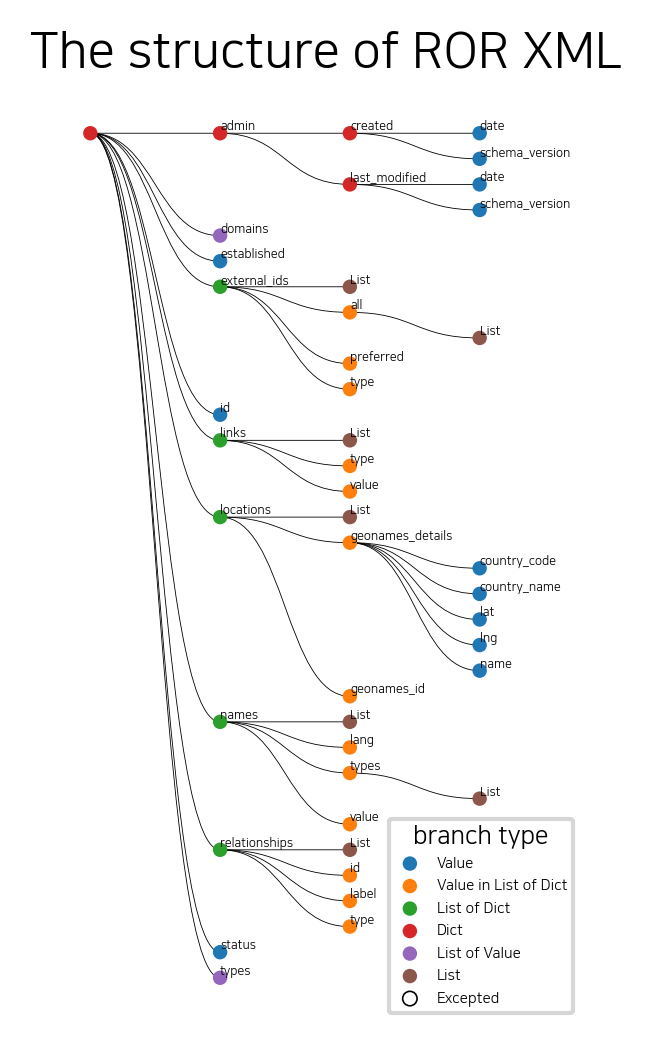

In [47]:
data_name = "ROR"
# fig = plot.plot_schema(excepted_reg[0], data_name=origin, origin=origin, except_keys=except_keys, forced={},
#           legend_loc='center left', node_size=12, font_size=3, X_SIZE=4, Y_SIZE=4, DPI=300
#                 )
fig = plot.plot_schema(
    sample,
    data_name=data_name,
    origin=origin,
    except_keys=except_keys,
    forced={},
    legend_loc="best",
    node_size=12,
    font_size=3,
    X_SIZE=2,
    Y_SIZE=3.6,
    DPI=300,  # right_margin_ratio
)
plt.tight_layout()
plt.savefig(f"{path}/json_structure.svg")

In [29]:
data_config = {
    "PATH": path,
    "KEY": "id",
    "SEP": "__",
    "table_name": "RoR",
    "Conv_DATETIME": False,
    "fname_index": True,
}

processing.save_data([df, df_subs], data_config)

'/Data/Data/RoR/01__RoR__MAIN.ftr' is successfully saved.
'/Data/Data/RoR/02__RoR__SUB__domains.ftr' is successfully saved.
'/Data/Data/RoR/03__RoR__SUB__external_ids.ftr' is successfully saved.
'/Data/Data/RoR/04__RoR__SUB__links.ftr' is successfully saved.
'/Data/Data/RoR/05__RoR__SUB__locations.ftr' is successfully saved.
'/Data/Data/RoR/06__RoR__SUB__names.ftr' is successfully saved.
'/Data/Data/RoR/07__RoR__SUB__relationships.ftr' is successfully saved.
'/Data/Data/RoR/08__RoR__SUB__types.ftr' is successfully saved.


In [12]:
len(df_subs)

7

In [34]:
params = dict(
    Extra_ratio=1.5,
    Min_Year=1900,
    Max_Year=2100,
    unique_ratio_th=0.2, # low value for multiple values
    freq_ratio_th=1e-3,
)

PATH = data_config["PATH"]
flist = sorted([x for x in os.listdir(PATH) if ".ftr" in x])
df_descs = []
_flist = []
for f in flist:
    data_config = preview.update_data_config(f, data_config)
    try:
        df_desc = preview.get_Table_Description(data_config, params)
        df_descs.append(df_desc)
        _flist.append(f)
    except:
        print(f"Fail to make description file with {f}.")

/workspace/1.1.KISTI_DB_Manager/KISTI_DB_Manager/preview.py:174: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'DATETIME' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  _res[_item] = _values[i]
/workspace/1.1.KISTI_DB_Manager/KISTI_DB_Manager/preview.py:201: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  _res[_item] = _desc[_item]
/workspace/1.1.KISTI_DB_Manager/KISTI_DB_Manager/preview.py:174: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'DATETIME' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  _res[_item] = _values[i]
/workspace/1.1.KISTI_DB_Manager/KISTI_DB_Ma

Generate the Description file for table `01__RoR__MAIN`
Generate the Description file for table `02__RoR__SUB__domains`
Generate the Description file for table `03__RoR__SUB__external_ids`
Generate the Description file for table `04__RoR__SUB__links`
Generate the Description file for table `05__RoR__SUB__locations`
Generate the Description file for table `06__RoR__SUB__names`
Generate the Description file for table `07__RoR__SUB__relationships`
Generate the Description file for table `08__RoR__SUB__types`


<Figure size 640x480 with 0 Axes>

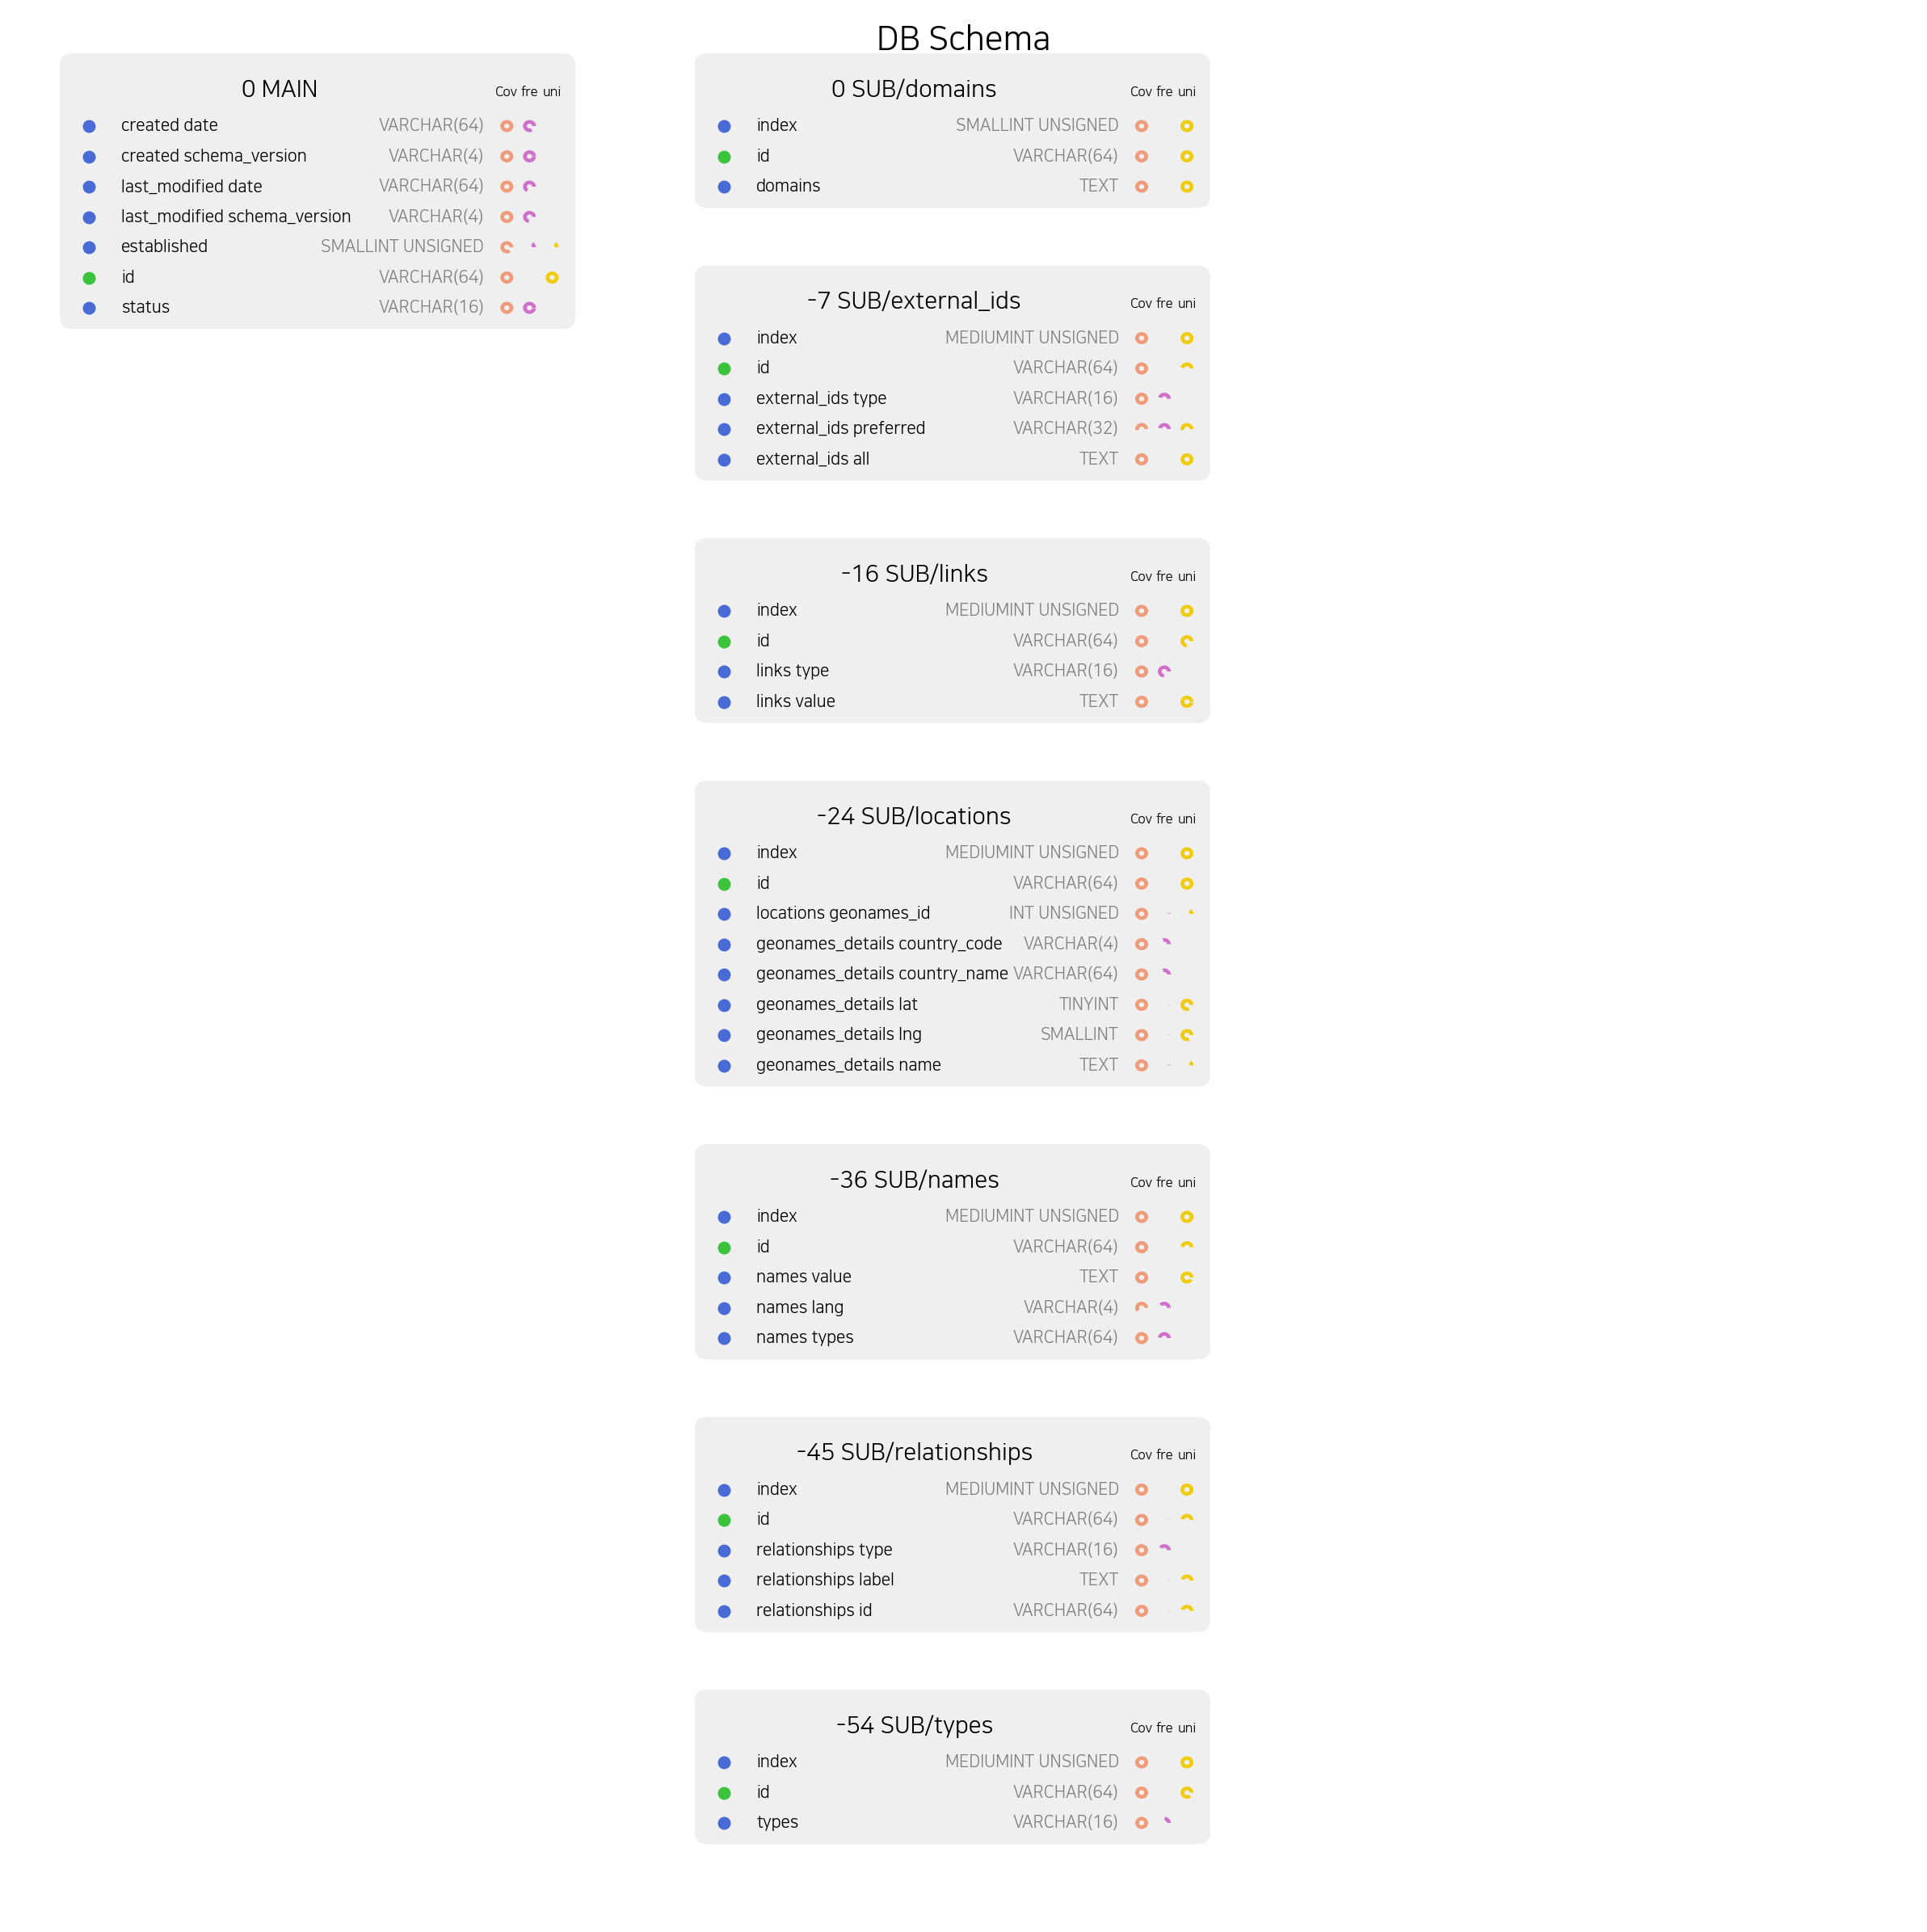

In [36]:
# legend_loc='center left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=5, DPI=300
node_size = 8
font_size = 5
X_SIZE = 10
Y_SIZE = 16
DPI = 300

title = "DB Schema"
sep = "__"
x_unit = 1
table_unit = x_unit * 6
features = ["Coverage", "freq", "uniq_ratio"]

# plt.rcParams['svg.fonttype'] = 'path'
svg_fonttype = "none"
# svg.fonttype : 'path'         # How to handle SVG fonts:
#    'none': Assume fonts are installed on the machine where the SVG will be viewed.
#    'path': Embed characters as paths -- supported by most SVG renderers
#    'svgfont': Embed characters as SVG fonts -- supported only by Chrome,
#               Opera and Safarids


fig = plot.draw_schema(df_descs, _flist, index_key, Y_SIZE=10)
plt.savefig(f"{path}schema.svg")

## Verbose

In [474]:
origin = ""
forced = {}
# key_pairs = json_to_key_pairs(jsons[:1000], origin)
key_pairs = json_to_key_pairs(extracted_dict[:1000], origin)
key_pairs_df = key_pair_to_df(key_pairs)
# key_pairs_df = processing.key_pair_to_df(key_pairs)
# key_pairs_df

	: 100%|█████████████████████████████████| 1000/1000 [00:00<00:00, 12077.69it/s]


In [473]:
def key_pair_to_df(key_pairs, sep="__"):
    """
    New Version
    """
    cols = ["type", "dtype", "parent", "branch"]
    _cols = ["type", "parent", "branch"]
    temp = pd.DataFrame(list(set(key_pairs)), columns=cols)  # .sort_values(_cols)
    temp["note"] = ""
    temp["count"] = 1

    new_cols = ["parent", "branch", "type", "dtype"]
    temp = (
        temp.reset_index()
        .fillna("")
        .groupby(new_cols)
        .sum()["count"]
        .unstack()
        .fillna(0)
        .astype(int)
    )

    midx = [[a for a, b, c in temp.index], [b for a, b, c in temp.index]]
    res = pd.DataFrame(
        [], index=pd.MultiIndex.from_arrays(midx, names=("parent", "branch"))
    )
    res["note"] = ""
    res["type"] = ""
    for parent in temp.index.levels[
        0
    ]:  # .reset_index().groupby(['parent', 'branch', 'type']).sum()
        temp2 = temp.xs(parent)
        for branch in temp2.reset_index()["branch"].values:  # temp2.index.levels[0]:
            pinotype = ""
            # Determine offspring
            idx = (parent, branch)
            temp3 = temp2.xs(branch)
            if len(temp3) > 1:
                pinotype = "List of Dict"
            elif temp3.index[0] == "Dict":
                pinotype = "Dict"
            elif temp3.index[0] == "List of Value":
                pinotype = "List"
            elif temp3.index[0] == "Value":
                pinotype = "Value"
            elif temp3.index[0] == "Value in List of Dict":
                try:
                    temp4 = temp.xs(branch)
                    if temp4.index[0][1] == "List":
                        pinotype = "Dict"
                        _idx = (sep.join(branch.split(sep)[:-1]), branch)
                        res.loc[_idx, "type"] = pinotype
                        _idx = (branch, branch + sep + "List")
                        res.loc[_idx, "type"] = "List"
                    elif all(temp4.reset_index()["type"].values == "Value"):
                        pinotype = "Dict"
                    else:
                        # print(temp3, offspring, temp4, (temp4.index.values))
                        print("Unexpected type!!")
                except:
                    pinotype = "Value"
            elif temp3.index[0] == "List of Dict":
                pinotype = "List of Dict"
            if pinotype != "":
                res.loc[idx, "type"] = pinotype
    return res.reset_index().drop_duplicates().reset_index(drop=True)

In [277]:
def json_to_key_pairs(json_data, parent=None, parent_type=None, result=None, sep="__"):

    _Types = {
        "l": "List",
        "lv": "List of Value",
        "ld": "List of Dict",
        "vld": "Value in List of Dict",
        "d": "Dict",
        "v": "Value",
    }

    def get_res(__json_data, parent=None, parent_type=None, result=None, sep="__"):
        if result is None:
            result = [(_Types["d"], type(__json_data).__name__, np.nan, parent)]

        if isinstance(__json_data, dict):
            for key, value in __json_data.items():
                child_type = (
                    _Types["d"]
                    if isinstance(value, dict)
                    else _Types["lv"] if isinstance(value, list) else _Types["v"]
                )
                try:
                    if any(isinstance(i, dict) for i in value):
                        child_type = _Types["ld"]
                except:
                    pass
                if parent == None:
                    new_parent = key
                else:
                    new_parent = parent + sep + key
                result.append(
                    (child_type, type(__json_data).__name__, parent, new_parent)
                )
                get_res(value, new_parent, child_type, result)
        elif isinstance(__json_data, list):
            item_type = (
                _Types["ld"]
                if any(isinstance(i, dict) for i in __json_data)
                else _Types["lv"]
            )
            # If the list contains dictionaries, treat each key in those dictionaries
            if item_type == _Types["ld"]:
                for item in __json_data:
                    if isinstance(item, dict):
                        for key in item:
                            if parent_type == _Types["ld"]:
                                item_type = _Types["vld"]
                            if parent == None:
                                new_parent = key
                            else:
                                new_parent = parent + sep + key
                            result.append(
                                (
                                    item_type,
                                    type(__json_data).__name__,
                                    parent,
                                    new_parent,
                                )
                            )
                            get_res(item[key], new_parent, item_type, result)
            # For lists of primitives, skip adding them directly but mark the presence of a list
            elif parent_type != _Types["lv"]:
                if parent is not None:
                    result.append(
                        (
                            _Types["l"],
                            type(__json_data).__name__,
                            parent,
                            parent + sep + _Types["l"],
                        )
                    )
        return result

    if isinstance(json_data, list):
        res = []
        for _json_data in tqdm(json_data, desc="\t", mininterval=1):  # ncols=90,
            _res = get_res(_json_data)
            res += _res
    else:
        res = get_res(json_data)
    res = pd.DataFrame(res).fillna(parent).dropna().values.tolist()
    return [tuple(l) for l in res]

In [498]:
sep = "__"
origin = ""
types = key_pairs_df.reset_index().set_index("branch")["type"]
index_key = "id"

# When The Structure is stiff. with except_keys
# except_key = ['dynamic_data']
# df, df_subs, excepted_part = processing.extract_data_from_jsons(jsons[:], index_key, except_keys)
# When The Structure is unstable.
excepted_reg = excepted_regularization(extracted_dict[:1000], types, base_key=origin)
df_ex, df_ex_subs, excepted_part = processing.extract_data_from_jsons(
    excepted_reg, index_key
)

	: 100%|███████████████████████████████████| 1000/1000 [00:03<00:00, 272.33it/s]


In [491]:
def excepted_regularization(_jsons, types, base_key="", sep="__"):
    def __init():
        _res = {}
        for branch in types.index:
            keys = branch.split(sep)[:]
            __type = types[branch]
            __res = _res
            for key in keys[:-1]:
                if isinstance(__res, list):
                    __res = __res[0]
                try:
                    __res = __res[key]
                except:
                    __res[key] = {}
                    __res = __res[key]
            if len(keys) > 0:
                fkey = keys[-1]
                if isinstance(__res, list):
                    __res = __res[0]

                if __type == "Value":
                    __res[fkey] = ""
                elif __type == "List":
                    __res[fkey] = []
                elif (
                    __type == "List of Dict"
                ):  # Assume I: 'Values in List of Dict' is not empty
                    __res[fkey] = [{}]
                elif __type == "Value in List of Dict":
                    __res[fkey] = ""
                elif __type == "Dict":
                    __res[fkey] = {}
                else:  # List
                    __res[fkey] = []

                if isinstance(__res, list):
                    __res = __res[0]

        return _res

    def get_value(__data, keys):
        if isinstance(keys, list) and len(keys) > 0:
            if isinstance(__data, dict):
                return get_value(__data[keys[0]], keys[1:])
            elif isinstance(__data, list):
                return get_value(__data[0], keys)
        else:
            # print(__data)  # For debugging; you might want to remove this in the final version
            return __data if not isinstance(__data, dict) else __data.copy()

    def insert_value(data, __res, full_key=""):
        if isinstance(data, dict):
            for k, v in data.items():
                if full_key != "":
                    _full_key = full_key + sep + k
                else:
                    _full_key = k

                if types[_full_key] == "Value":
                    # print('V**', v, _full_key, '\n')
                    __res[k] = v  # Init is ''
                elif types[_full_key] == "Value in List of Dict":
                    # print('VLD**', v, k, data, '\n')
                    __res[k] = v  # Init is ''
                elif types[_full_key] == "Dict":
                    # if _full_key == 'static_data__summary__titles__title':
                    # print('D**', v, _full_key, '\n')
                    insert_value(v, __res[k], _full_key)
                elif types[_full_key] == "List of Dict":
                    # if _full_key == 'static_data__summary__titles__title':
                    # print('LD*', __res, v, k, data)
                    _keys = _full_key.split(sep)
                    if type(v) != list:  # '0'번째에 채워넣기
                        format = get_value(__init(), _keys)[0]
                        for k2, v2 in v.items():
                            format[k2] = v2
                        __res[k][0] = format
                    else:  # 덮어서 붙여넣기 (해도 되나?)
                        # print('LD*', __res, v, k)
                        _formats = []
                        for _v in v:
                            format = get_value(__init(), _keys)[0]
                            for k2, v2 in _v.items():
                                format[k2] = v2
                            _formats.append(format)
                        # print('$$$$', _formats)
                        __res[k] = _formats

                        # __res[k].append(v)
                elif types[_full_key] == "List":
                    if type(v) != list:  # '0'번째에 채워넣기
                        v = [v]
                    # for _v in v:
                    __res[k] = v
                    # insert_value(_v, __res[k], _full_key)
                else:
                    pass
                    # print('*****', types[_full_key])
                    # break

        elif isinstance(data, list):
            for item in data:
                if types[full_key] == "Value":
                    # print('VoL*', item, data, full_key)
                    __res = item  # Init is ''
                elif types[full_key] == "Value in List of Dict":
                    # print('VLDoL*', item, data, full_key)
                    __res = item  # Init is ''
                elif types[full_key] == "Dict":
                    # print('DoL*', item, data,full_key)
                    for k, v in item.items():
                        if full_key != "":
                            _full_key = full_key + sep + k
                        else:
                            _full_key = k
                        insert_value(item, __res[k], _full_key)
                elif types[full_key] == "List of Dict":
                    # print('LD*', __res, v, k)
                    for k, v in item.items():
                        if full_key != "":
                            _full_key = full_key + sep + k
                        else:
                            _full_key = k
                        insert_value(_v, __res, _full_key)
                    # for _v in item:
                    #     insert_value(_v, __res, _full_key)
                elif types[_full_key] == "List":
                    __res.append(item)
                    # print('EoL*', item, data,full_key)
                else:
                    pass
                    # print('*****', types[_full_key])
                    # break
        else:
            if types[full_key] == "List":
                print("LV*", data, __res, full_key)
                # insert_value(data, __res, full_key)
                __res = data
            elif data == None:
                # 데이타 없어서 걍 넘어가도 기본형식으로 채워짐
                pass
            else:
                print("E*", types[full_key], data, __res, full_key)

    result = []
    types = types.iloc[1:]
    for _json in tqdm(
        _jsons, desc="\t", mininterval=1  # ncols=90,
    ):  # , bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt}", mininterval=1):
        _res = __init().copy()
        insert_value(_json, _res, base_key)
        result.append(_res)
    return result

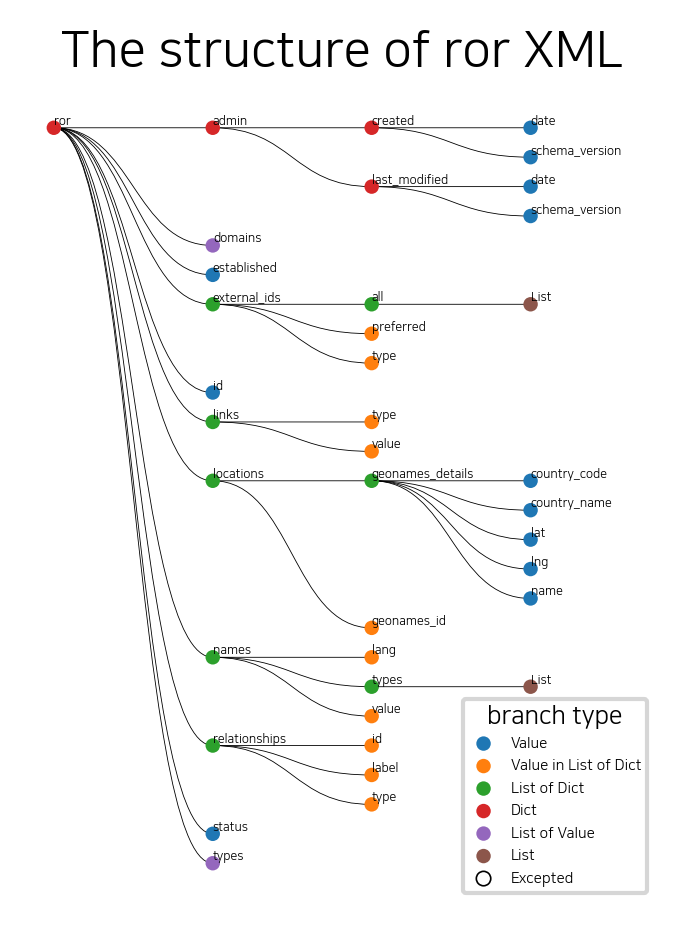

In [111]:
except_keys = []
origin = "ror"
# fig = plot.plot_schema(excepted_reg[0], data_name=origin, origin=origin, except_keys=except_keys, forced={},
#           legend_loc='center left', node_size=12, font_size=3, X_SIZE=4, Y_SIZE=4, DPI=300
#                 )
fig = plot.plot_schema(
    excepted_reg[0],
    data_name=origin,
    origin=origin,
    except_keys=except_keys,
    forced={},
    legend_loc="best",
    node_size=12,
    font_size=3,
    X_SIZE=2,
    Y_SIZE=3.2,
    DPI=300,
)
plt.tight_layout()
# plt.savefig("Structure_WoS_XML.svg")

## Insert

In [37]:
Port = 3306  # Port for DB with host
CHARACTER_SET = "utf8mb4"
COLLATE = "utf8mb4_unicode_520_ci"

params = dict(
    Extra_ratio=1.5,
    Min_Year=1900,
    Max_Year=2100,
    unique_ratio_th=0.5,
    freq_ratio_th=1e-3,
)

db_config = {
    "host": "172.16.2.93",  # Update as needed
    "user": "root",  # Update as needed
    "password": "1234",  # Update as needed
    "database": "ror_v1.51-2024-08-21",  # Update as needed
}

data_config = {
    "PATH": path,
    "SEP": sep,
    "file_name": "file_name",  # Dummy init value
    "file_type": "csv",  # Dummy init value
    "table_name": "table_name",  # Dummy init value for Exporting
    "out_path": path,  # Update as needed
    "Conv_DATETIME": False,
}

In [44]:
flist = sorted([x for x in os.listdir(PATH) if ".ftr" in x])
# flist2 = sorted([x for x in os.listdir(PATH) if 'Desc.csv' in x])

manage.init_MySQL()
try:
    manage.drop_DB(db_config["database"], db_config)
except:
    pass
manage.create_DB(db_config["database"], CHARACTER_SET, COLLATE, db_config)

desclist = sorted([x for x in os.listdir(PATH) if "Desc.csv" in x])
# Generate the Tabular File list
for i, f in enumerate(tqdm(flist[:], desc="Insert to SQL:")):
    data_config = preview.update_data_config(f, data_config)
    # df_desc = preview.get_Table_Description(data_config, params)
    df_desc = pd.read_csv(f"{path}{desclist[i]}")

    # Generate and execute CREATE TABLE SQL
    manage.create_table(data_config, db_config)
    manage.fill_table_from_file(data_config, db_config)
    manage.set_index(db_config, data_config)
    manage.optimize_table(db_config, data_config)

mysql: unrecognized service


Database `ror-v1.51-2024-08-21` dropped successfully.
Database `ror-v1.51-2024-08-21` created successfully.


Insert to SQL::   0%|                                     | 0/8 [00:00<?, ?it/s]

Table `01__RoR__MAIN` created successfully.
Data inserted into table `01__RoR__MAIN` successfully.
Set Index the `id` on `01__RoR__MAIN` successfully.


Insert to SQL::  12%|███▋                         | 1/8 [00:03<00:21,  3.07s/it]

...

Optimize table `06__RoR__SUB__names` successfully.
Table `07__RoR__SUB__relationships` created successfully.
Data inserted into table `07__RoR__SUB__relationships` successfully.
Set Index the `id` on `07__RoR__SUB__relationships` successfully.


Insert to SQL::  88%|█████████████████████████▍   | 7/8 [00:33<00:05,  5.05s/it]

Optimize table `07__RoR__SUB__relationships` successfully.
Table `08__RoR__SUB__types` created successfully.
Data inserted into table `08__RoR__SUB__types` successfully.
Set Index the `id` on `08__RoR__SUB__types` successfully.


Insert to SQL:: 100%|█████████████████████████████| 8/8 [00:35<00:00,  4.46s/it]

Optimize table `08__RoR__SUB__types` successfully.


In [26]:
i = 4
f = flist[i]
data_config = preview.update_data_config(f, data_config)
# df_desc = preview.get_Table_Description(data_config, params)
df_desc = df_descs[i]

# Generate and execute CREATE TABLE SQL
manage.create_table(data_config, db_config)
manage.fill_table_from_file(data_config, db_config)
manage.set_index(db_config, data_config)
manage.optimize_table(db_config, data_config)

Error: (1050, "Table '05__RoR_Sample__MN-SUB__locations' already exists")
Data inserted into table `05__RoR_Sample__MN-SUB__locations` successfully.
Failed to create index `05__RoR_Sample__MN-SUB__locations`. Error: (1064, "You have an error in your SQL syntax; check the manual that corresponds to your MariaDB server version for the right syntax to use near 'index)' at line 1") with CREATE INDEX `IDX_05__ROR_SAMPLE__MN-SUB__LOCATIONS_INDEX` ON `05__RoR_Sample__MN-SUB__locations` (index);
Optimize table `05__RoR_Sample__MN-SUB__locations` successfully.


In [39]:
df

,admin__created__date,admin__created__schema_version,admin__last_modified__date,admin__last_modified__schema_version,established,id,status
0,2018-11-14,1.0,2024-05-13,2.0,1887,https://ror.org/04ttjf776,active
1,2018-11-14,1.0,2024-05-13,2.0,1964,https://ror.org/01rxfrp27,active
2,2018-11-14,1.0,2024-05-13,2.0,1916,https://ror.org/04j757h98,active
3,2018-11-14,1.0,2024-05-13,2.0,1938,https://ror.org/04r659a56,active
4,2018-11-14,1.0,2024-05-13,2.0,1971,https://ror.org/02sc3r913,active
...,...,...,...,...,...,...,...
110479,2023-11-08,1.0,2024-08-21,2.0,None,https://ror.org/01qwmf693,withdrawn
110480,2024-08-19,2.0,2024-08-21,2.0,2015,https://ror.org/02gqdm821,active
110481,2018-11-14,1.0,2024-08-21,2.0,1970,https://ror.org/01gyxrk03,active
110482,2024-08-19,2.0,2024-08-21,2.0,None,https://ror.org/0279hze33,active


In [41]:
df_descs[0]

,Description,Type,Example,Coverage,min,max,mean,std,top,uniq,freq,entr,Failed,_max_range,uniq_ratio,Null_ratio,is_key
admin__created__date,,VARCHAR(64),2018-11-14,1.0,2018-11-14 00:00:00,2024-08-19 00:00:00,NaN,NaN,2018-11-14,58,0.829306,1.448795,False,-,0.000525,0.01,False
admin__created__schema_version,,VARCHAR(4),1.0,1.0,3,3,NaN,NaN,1.0,2,0.986849,0.101025,False,4,0.000018,0.01,False
admin__last_modified__date,,VARCHAR(64),2024-05-13,1.0,2021-03-17 00:00:00,2024-08-21 00:00:00,NaN,NaN,2024-05-13,56,0.671835,1.541309,False,-,0.000507,0.01,False
admin__last_modified__schema_version,,VARCHAR(4),2.0,1.0,3,3,NaN,NaN,2.0,2,0.725825,0.847393,False,4,0.000018,0.01,False
established,,SMALLINT UNSIGNED,1887.0,0.849028,712,2024,1968.053814,56.277179,NaN,17295,0.150972,6.162066,False,65534,0.156539,0.01,False
id,,VARCHAR(64),https://ror.org/04ttjf776,1.0,25,25,NaN,NaN,https://ror.org/02e15es11,110484,0.000009,16.753478,False,37,1.0,0.01,True
status,,VARCHAR(16),active,1.0,6,9,NaN,NaN,active,3,0.982559,0.14339,False,13,0.000027,0.01,False


In [45]:
df_subs['names']

,id,names__value,names__lang,names__types
0,https://ror.org/04ttjf776,RMIT,None,[acronym]
1,https://ror.org/04ttjf776,RMIT University,en,"[ror_display, label]"
2,https://ror.org/04ttjf776,Royal Melbourne Institute of Technology Univer...,en,[alias]
3,https://ror.org/01rxfrp27,La Trobe University,en,"[ror_display, label]"
4,https://ror.org/04j757h98,VU,None,[acronym]
...,...,...,...,...
224577,https://ror.org/0279hze33,Citizens Financial Group (United States),en,"[label, ror_display]"
224578,https://ror.org/0279hze33,Citizens Financial Group Inc,en,[alias]
224579,https://ror.org/02e15es11,Marathon Petroleum,en,[label]
224580,https://ror.org/02e15es11,Marathon Petroleum (United States),en,"[label, ror_display]"


In [23]:
df_subs['external_ids']

,id,external_ids__type,external_ids__preferred,external_ids__all
0,https://ror.org/04ttjf776,fundref,501100001780,"[501100001780, 100008690, 100010552]"
1,https://ror.org/04ttjf776,grid,grid.1017.7,[grid.1017.7]
2,https://ror.org/04ttjf776,isni,None,[0000 0001 2163 3550]
3,https://ror.org/04ttjf776,wikidata,None,[Q1057890]
4,https://ror.org/01rxfrp27,fundref,None,[501100001215]
...,...,...,...,...
227859,https://ror.org/01qwmf693,isni,0000 0000 9289 1250,[0000 0000 9289 1250]
227860,https://ror.org/01qwmf693,wikidata,Q1433308,[Q1433308]
227861,https://ror.org/01gyxrk03,grid,grid.11162.35,[grid.11162.35]
227862,https://ror.org/01gyxrk03,isni,None,[0000 0001 0789 1385]


In [ ]:
for i, f in enumerate(tqdm(flist[:], desc="Insert to SQL:")):
    data_config = preview.update_data_config(f, data_config)
    # df_desc = preview.get_Table_Description(data_config, params)
    df_desc = df_descs[i]

    # Generate and execute CREATE TABLE SQL
    manage.create_table(data_config, db_config)
    manage.fill_table_from_file(data_config, db_config)
    manage.set_index(db_config, data_config)
    manage.optimize_table(db_config, data_config)

In [19]:
manage.backup_database_pymysql(db_config, data_config)

Backup completed successfully. File saved at: /Data/Data/RoR/ror-v1.51-2024-08-21_backup.sql


In [21]:
!ls /Data/Data/RoR/ -lh

total 181M
-rwxrwxrwx 1 root root 4.5M Sep 20 03:12 01__RoR_Sample__MN.ftr
-rwxrwxrwx 1 root root 1.3K Sep 20 03:12 01__RoR_Sample__MN_Desc.csv
-rwxrwxrwx 1 root root  34K Sep 20 03:12 02__RoR_Sample__MN-SUB__domains.ftr
-rwxrwxrwx 1 root root  468 Sep 20 03:12 02__RoR_Sample__MN-SUB__domains_Desc.csv
-rwxrwxrwx 1 root root 8.7M Sep 20 03:12 03__RoR_Sample__MN-SUB__external_ids.ftr
-rwxrwxrwx 1 root root  917 Sep 20 03:12 03__RoR_Sample__MN-SUB__external_ids_Desc.csv
-rwxrwxrwx 1 root root 5.8M Sep 20 03:12 04__RoR_Sample__MN-SUB__links.ftr
-rwxrwxrwx 1 root root  755 Sep 20 03:12 04__RoR_Sample__MN-SUB__links_Desc.csv
-rwxrwxrwx 1 root root 6.0M Sep 20 03:12 05__RoR_Sample__MN-SUB__locations.ftr
-rwxrwxrwx 1 root root 1.5K Sep 20 03:12 05__RoR_Sample__MN-SUB__locations_Desc.csv
-rwxrwxrwx 1 root root  11M Sep 20 03:12 06__RoR_Sample__MN-SUB__names.ftr
-rwxrwxrwx 1 root root  869 Sep 20 03:12 06__RoR_Sample__MN-SUB__names_Desc.csv
-rwxrwxrwx 1 root root 2.5M Sep 20 03:12 07__RoR_Sample

# Analy Ver.

In [223]:
import sys

import pymysql

sys.path.append("/workspace/1.1.KISTI_DB_Manager/")

import importlib as imp

from KISTI_DB_Manager import manage, plot, preview, processing

imp.reload(manage), imp.reload(preview), imp.reload(processing), imp.reload(plot)

(<module 'KISTI_DB_Manager.manage' from '/workspace/1.1.KISTI_DB_Manager/KISTI_DB_Manager/manage.py'>,
 <module 'KISTI_DB_Manager.preview' from '/workspace/1.1.KISTI_DB_Manager/KISTI_DB_Manager/preview.py'>,
 <module 'KISTI_DB_Manager.processing' from '/workspace/1.1.KISTI_DB_Manager/KISTI_DB_Manager/processing.py'>,
 <module 'KISTI_DB_Manager.plot' from '/workspace/1.1.KISTI_DB_Manager/KISTI_DB_Manager/plot.py'>)

## Additional Update

In [169]:
flist = sorted([x for x in os.listdir(PATH) if ".ftr" in x])
flist

['01__RoR__MAIN.ftr',
 '02__RoR__SUB__domains.ftr',
 '03__RoR__SUB__external_ids.ftr',
 '04__RoR__SUB__links.ftr',
 '05__RoR__SUB__locations.ftr',
 '06__RoR__SUB__names.ftr',
 '07__RoR__SUB__relationships.ftr',
 '08__RoR__SUB__types.ftr']

In [155]:
flist = sorted([x for x in os.listdir(PATH) if ".ftr" in x])
flist

# flist = sorted([x for x in os.listdir(path+'v1/') if ".ftr" in x])
# flist

['01__RoR__MAIN.ftr',
 '02__RoR__SUB__domains.ftr',
 '03__RoR__SUB__external_ids.ftr',
 '04__RoR__SUB__links.ftr',
 '05__RoR__SUB__locations.ftr',
 '06__RoR__SUB__names.ftr',
 '07__RoR__SUB__relationships.ftr',
 '08__RoR__SUB__types.ftr']

In [175]:
del(df_subs)
df_subs = dict()

for i, f in enumerate(flist):
    if i == 0:
        df = pd.read_feather(path+f)
    else:
        field = f.split(sep)[-1][:-4]
        df_subs[field] = pd.read_feather(path+f)
        if 'index' in df_subs[field].columns:
            del(df_subs[field]['index'])

# for i, f in enumerate(flist):
#     if i == 0:
#         df = pd.read_feather(path+'v1/'+f)
#     else:
#         field = f.split(sep)[-1][:-4]
#         df_subs[field] = pd.read_feather(path+'v1/'+f)
#         # if 'index' in df_subs[field].columns:
#         #     del(df_subs[field]['index'])

In [176]:
# 옵션 설정
options = {
    'replace_delimiters': True,
    'sub_df_simplify': True
}

# 함수 호출
manage.rename_columns(df, df_subs, options)

# Exception_field
cols = df_subs['relationships'].columns.values
cols[-1] = 'relationships_id'
df_subs['relationships'].columns = cols

### Add ror_display_name

In [177]:
msk = df_subs['names']['types'].apply(lambda x: 'ror_display' in x)
names = df_subs['names'][msk][['id', 'value']]
df = pd.merge(df, names, on='id')

cols = df.columns.values
cols[-1] = 'display_name'
df.columns = cols

## Process

In [200]:
data_config = {
    "PATH": path+"v1/",
    "KEYS": ["id"],
    "SEP": "_",
    "table_name": "RoR",
    "Conv_DATETIME": False,
    "fname_index": False,
}

processing.save_data([df, df_subs], data_config)

'/Data/Data/RoR/v1/RoR_MAIN.ftr' is successfully saved.
'/Data/Data/RoR/v1/RoR_SUB_domains.ftr' is successfully saved.
'/Data/Data/RoR/v1/RoR_SUB_external_ids.ftr' is successfully saved.
'/Data/Data/RoR/v1/RoR_SUB_links.ftr' is successfully saved.
'/Data/Data/RoR/v1/RoR_SUB_locations.ftr' is successfully saved.
'/Data/Data/RoR/v1/RoR_SUB_names.ftr' is successfully saved.
'/Data/Data/RoR/v1/RoR_SUB_relationships.ftr' is successfully saved.
'/Data/Data/RoR/v1/RoR_SUB_types.ftr' is successfully saved.


## Insert

In [146]:
i = 2
df_desc = pd.read_csv(f"{path}v1/{desclist[i]}")
df_desc

,Unnamed: 0,Description,Type,Example,Coverage,min,max,mean,std,top,uniq,freq,entr,Failed,_max_range,uniq_ratio,Null_ratio,is_key
0,index,NaN,MEDIUMINT UNSIGNED,0,1.000000,0,227863,113931.5,65778.815207,NaN,227864,0.000004,17.797813,False,16777214,1.000000,0.01,True
1,id,NaN,VARCHAR(64),https://ror.org/04ttjf776,1.000000,25,25,NaN,NaN,https://ror.org/046fa4y88,108446,0.000018,16.574814,False,37,0.475924,0.01,True
2,type,NaN,VARCHAR(16),fundref,1.000000,4,8,NaN,NaN,grid,4,0.454982,1.778624,False,12,0.000018,0.01,False
3,preferred,NaN,VARCHAR(32),501100001780,0.537119,4,19,NaN,NaN,Q6591593,122367,0.462881,9.559323,False,28,0.537018,0.01,False
4,all,NaN,TEXT,['501100001780' '100008690' '100010552'],1.000000,7,710,NaN,NaN,['Q6591593'],227684,0.000013,17.796230,False,1065,0.999210,0.01,False


In [202]:
Port = 3306  # Port for DB with host
CHARACTER_SET = "utf8mb4"
COLLATE = "utf8mb4_unicode_520_ci"

params = dict(
    Extra_ratio=1.5,
    Min_Year=1900,
    Max_Year=2100,
    unique_ratio_th=0.5,
    freq_ratio_th=1e-3,
)

db_config = {
    "host": "localhost",  # Update as needed
    "user": "root",  # Update as needed
    "password": "1234",  # Update as needed
    "database": "ror_2024_08_v1",  # Update as needed
}

data_config = {
    "PATH": path+"v1/",
    "SEP": sep,
    "KEYS": ["id"],
    "file_name": "file_name",  # Dummy init value
    "file_type": "csv",  # Dummy init value
    "table_name": "table_name",  # Dummy init value for Exporting
    "out_path": path,  # Update as needed
    "Conv_DATETIME": False,
}

In [203]:
flist = sorted([x for x in os.listdir(data_config["PATH"]) if ".ftr" in x])
# flist2 = sorted([x for x in os.listdir(PATH) if 'Desc.csv' in x])

manage.init_MySQL()
try:
    manage.drop_DB(db_config["database"], db_config)
except:
    pass
manage.create_DB(db_config["database"], CHARACTER_SET, COLLATE, db_config)

desclist = sorted([x for x in os.listdir(data_config["PATH"]) if "Desc.csv" in x])
# Generate the Tabular File list
for i, f in enumerate(tqdm(flist[:], desc="Insert to SQL:")):
    data_config = preview.update_data_config(f, data_config)
    df_desc = preview.get_Table_Description(data_config, params)
    # df_desc = pd.read_csv(f"{path}{desclist[i]}")

    # Generate and execute CREATE TABLE SQL
    manage.create_table(data_config, db_config)
    manage.fill_table_from_file(data_config, db_config)
    manage.set_index(db_config, data_config)
    manage.optimize_table(db_config, data_config)

mysql: unrecognized service


Database `ror_2024_08_v1` dropped successfully.
Database `ror_2024_08_v1` created successfully.


Insert to SQL::   0%|                                     | 0/8 [00:00<?, ?it/s]

Generate the Description file for table `RoR_MAIN`
Table `RoR_MAIN` created successfully.
Data inserted into table `RoR_MAIN` successfully.
Set Index the `id` on `RoR_MAIN` successfully.


Insert to SQL::  12%|███▋                         | 1/8 [00:04<00:34,  4.93s/it]

...

Optimize table `RoR_SUB_names` successfully.
Generate the Description file for table `RoR_SUB_relationships`
Table `RoR_SUB_relationships` created successfully.
Data inserted into table `RoR_SUB_relationships` successfully.
Set Index the `id` on `RoR_SUB_relationships` successfully.


Insert to SQL::  88%|█████████████████████████▍   | 7/8 [00:41<00:06,  6.09s/it]

Optimize table `RoR_SUB_relationships` successfully.
Generate the Description file for table `RoR_SUB_types`
Table `RoR_SUB_types` created successfully.
Data inserted into table `RoR_SUB_types` successfully.
Set Index the `id` on `RoR_SUB_types` successfully.


Insert to SQL:: 100%|█████████████████████████████| 8/8 [00:43<00:00,  5.46s/it]

Optimize table `RoR_SUB_types` successfully.


## 11

In [205]:
sample

{'admin': {'created': {'date': '2018-11-14', 'schema_version': '1.0'},
  'last_modified': {'date': '2024-05-13', 'schema_version': '2.0'}},
 'domains': [],
 'external_ids': [{'type': 'fundref',
   'all': ['501100001780', '100008690', '100010552'],
   'preferred': '501100001780'},
  {'type': 'grid', 'all': ['grid.1017.7'], 'preferred': 'grid.1017.7'},
  {'type': 'isni', 'all': ['0000 0001 2163 3550'], 'preferred': None},
  {'type': 'wikidata', 'all': ['Q1057890'], 'preferred': None}],
 'links': [{'type': 'website', 'value': 'https://www.rmit.edu.au/'},
  {'type': 'wikipedia',
   'value': 'http://en.wikipedia.org/wiki/RMIT_University'}],
 'locations': [{'geonames_id': 2158177,
   'geonames_details': {'country_code': 'AU',
    'country_name': 'Australia',
    'lat': -37.806748,
    'lng': 144.962573,
    'name': 'Melbourne'}}],
 'names': [{'value': 'RMIT', 'types': ['acronym'], 'lang': None},
  {'value': 'RMIT University',
   'types': ['ror_display', 'label'],
   'lang': 'en'},
  {'value'

branch
                                                              Dict
admin                                                         Dict
domains                                              List of Value
established                                                  Value
external_ids                                          List of Dict
id                                                           Value
links                                                 List of Dict
locations                                             List of Dict
names                                                 List of Dict
relationships                                         List of Dict
status                                                       Value
types                                                List of Value
admin__created                                                Dict
admin__last_modified                                          Dict
admin__created__date                                   

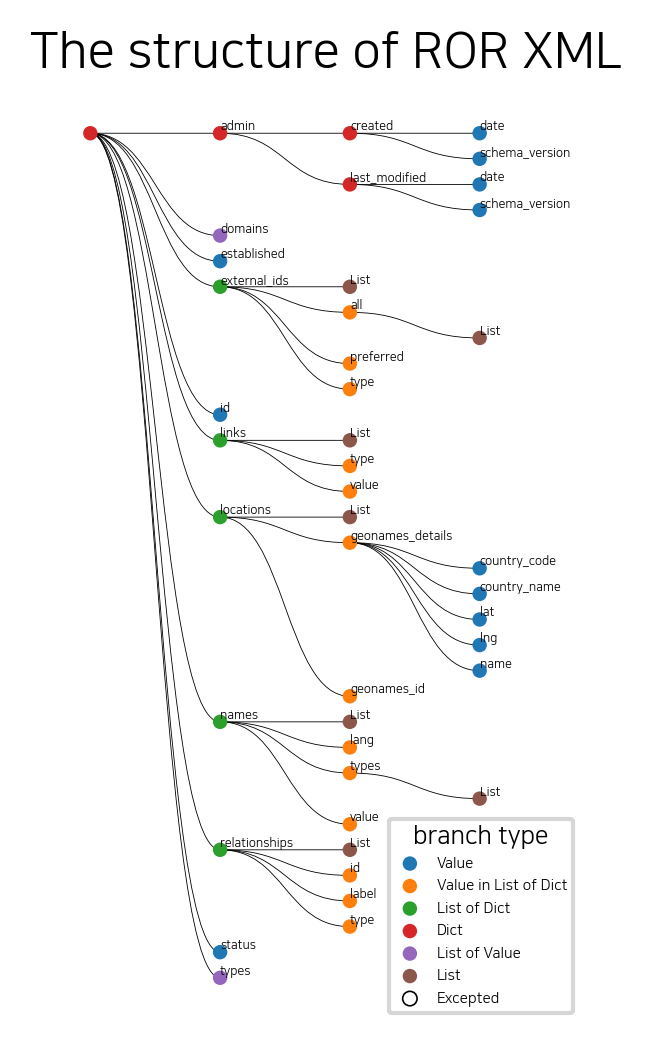

In [224]:
data_name = "ROR"
# fig = plot.plot_schema(excepted_reg[0], data_name=origin, origin=origin, except_keys=except_keys, forced={},
#           legend_loc='center left', node_size=12, font_size=3, X_SIZE=4, Y_SIZE=4, DPI=300
#                 )
fig = plot.plot_schema(
    sample,
    data_name=data_name,
    origin=origin,
    except_keys=except_keys,
    forced={},
    legend_loc="best",
    node_size=12,
    font_size=3,
    X_SIZE=2,
    Y_SIZE=3.6,
    DPI=300,  # right_margin_ratio
)
plt.tight_layout()
# plt.savefig(f"{path}/json_structure.svg")

In [210]:
_kp = processing.json_to_key_pairs([sample], parent='')
processing.key_pair_to_df(_kp)

,parent,branch,type
0,,,Dict
1,,admin,Value in List of Dict
2,,domains,Value in List of Dict
3,,established,Value in List of Dict
4,,external_ids,Value in List of Dict
5,,id,Value in List of Dict
6,,links,Value in List of Dict
7,,locations,Value in List of Dict
8,,names,Value in List of Dict
9,,relationships,Value in List of Dict


In [17]:
manage.backup_database_subprocess(db_config, data_config)

FileNotFoundError: [Errno 2] No such file or directory: 'mysqldump'

In [44]:
conn = pymysql.connect(**db_config)

OperationalError: (2003, "Can't connect to MySQL server on 'localhost' ([Errno 111] Connection refused)")